In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
import warnings

# مكتبات الذكاء الاصطناعي
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# تجاهل التحذيرات
warnings.filterwarnings('ignore')
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

print("🚀 Starting Fuel Price AI System (Analysis + GUI)...")

🚀 Starting Fuel Price AI System (Analysis + GUI)...


In [4]:
# 1. تجهيز البيانات (Data Processing)
# ==========================================
try:
    df = pd.read_csv('final_training_dataset.csv')    
    FUEL_MAPPING = {'Diesel (Solar)': 0, 'Natural Gas (CNG)': 1, 'Octane 80': 2, 'Octane 92': 3, 'Octane 95': 4}
    
    # تحويل الكلام لأرقام
    df['Fuel_Type_Code'] = df['Fuel_Type'].map(FUEL_MAPPING)
    df = df.dropna(subset=['Fuel_Type_Code'])
    
    # ---------------------------------------------------------
    # الخطوة الحاسمة: التقسيم يحصل الأول قبل أي تكرار!
    # ---------------------------------------------------------
    # هنا هنقسم الداتا فريم نفسها لجزئين
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

    # ---------------------------------------------------------
    # التكرار (Boosting) يتم على بيانات التدريب (train_df) فقط
    # ---------------------------------------------------------
    recent_data_train = train_df[train_df['Year'] >= 2024]
    
    if len(recent_data_train) > 0:
        # بنكرر البيانات الحديثة جوه الـ Train بس
        train_df = pd.concat([train_df] + [recent_data_train] * 50, ignore_index=True)
        print(f"Training data has been duplicated. New training size: {len(train_df)}")
    
    # دلوقتي نفصل X و y لكل مجموعة لوحدها
    # 1. تجهيز التدريب (المتكرر)
    X_train = train_df[['Fuel_Type_Code', 'Oil_3M_Avg', 'USD_3M_Avg', 'Year']]
    y_train = train_df['Price']
    
    # 2. تجهيز الاختبار (النضيف - بدون تكرار)
    X_test = test_df[['Fuel_Type_Code', 'Oil_3M_Avg', 'USD_3M_Avg', 'Year']]
    y_test = test_df['Price']
    
    # Scaling (توحيد المقامات)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

except Exception as e:
    print(f"❌ Error: {e}")
    exit()

Training data has been duplicated. New training size: 870


In [5]:
# 2. تعريف الموديلات (5 Models)
# ==========================================
models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=3, metric='manhattan'),#
    "Random Forest": RandomForestRegressor(n_estimators=1000, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=42)
}
# الموديل الخامس (المجمع)
ensemble = VotingRegressor(estimators=[(n, m) for n, m in models.items()])
models["Ensemble"] = ensemble   

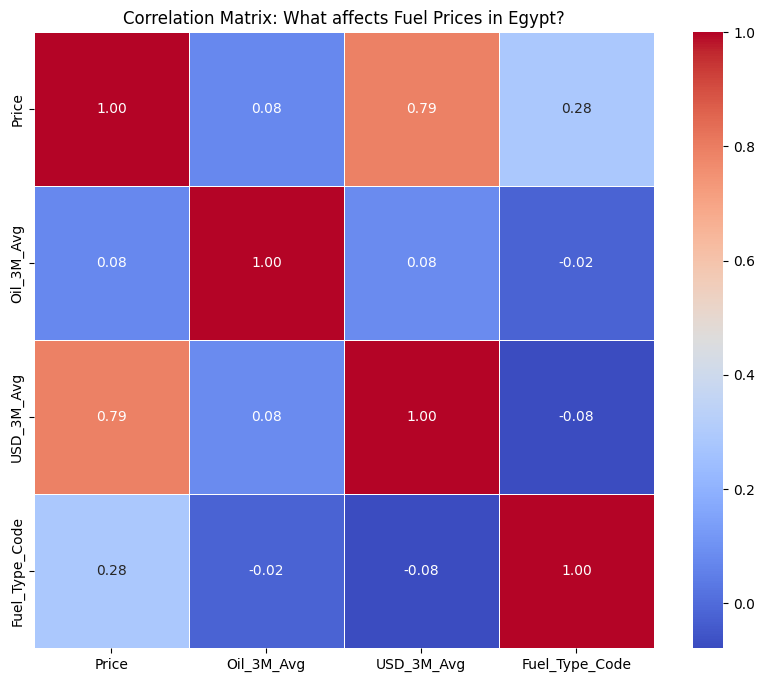

In [6]:

# هنختار الأعمدة المهمة بس اللي عايزين نشوف علاقتها ببعض
columns_to_plot = ['Price', 'Oil_3M_Avg', 'USD_3M_Avg', 'Fuel_Type_Code']
corr_matrix = df[columns_to_plot].corr()


# 3. رسم الـ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix: What affects Fuel Prices in Egypt?')
plt.show()


========== PART 1: Model Analysis (Plots & Tables) ==========

⚙️ Processing Linear Regression...
✅ Showing Plot for Linear Regression...


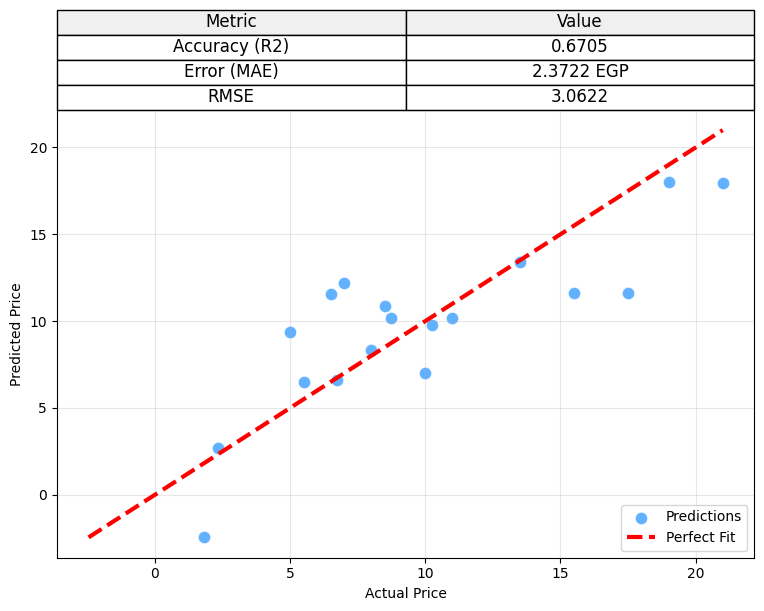

⚙️ Processing KNN...
✅ Showing Plot for KNN...


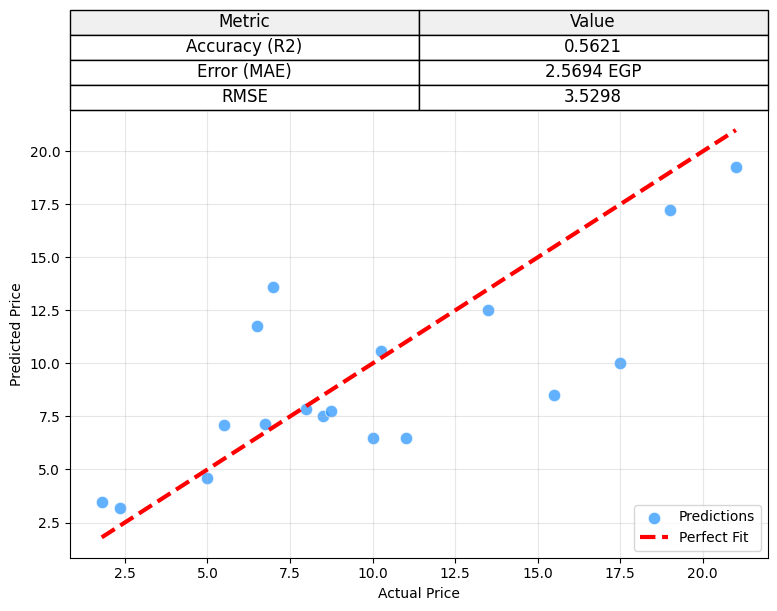

⚙️ Processing Random Forest...
✅ Showing Plot for Random Forest...


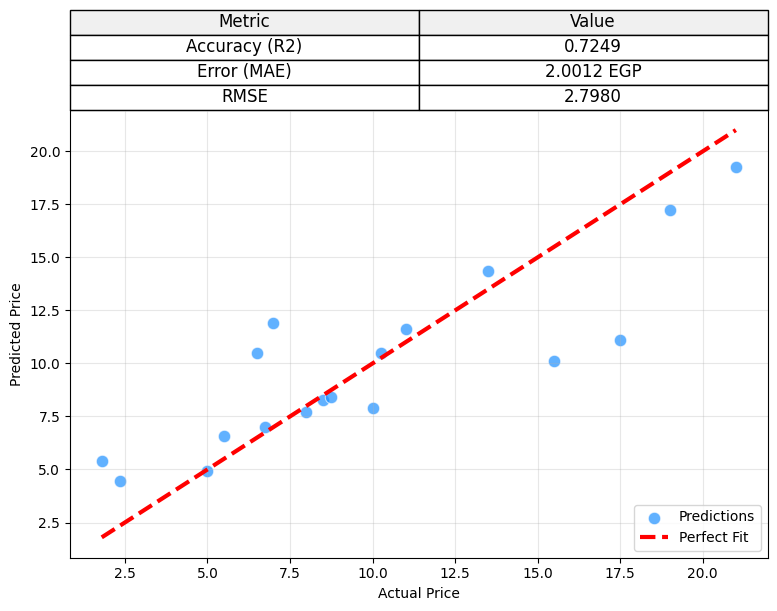

⚙️ Processing XGBoost...
✅ Showing Plot for XGBoost...


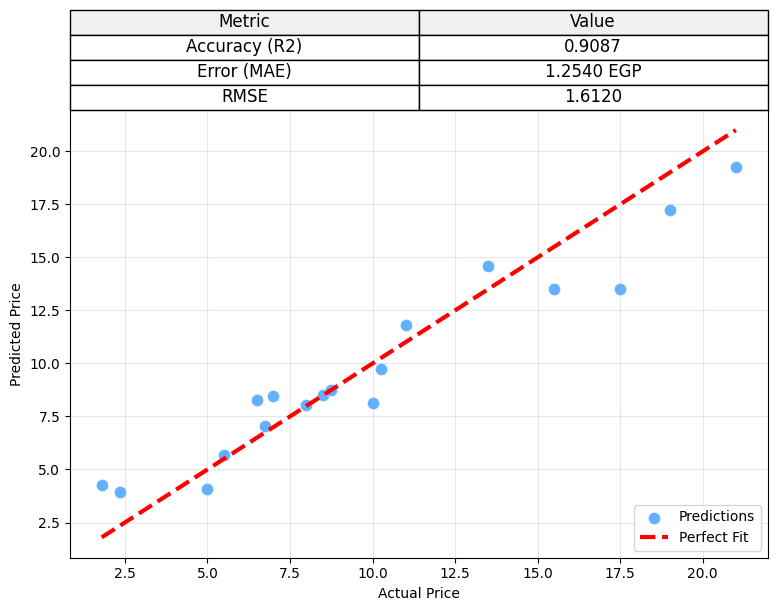

⚙️ Processing Ensemble...
✅ Showing Plot for Ensemble...


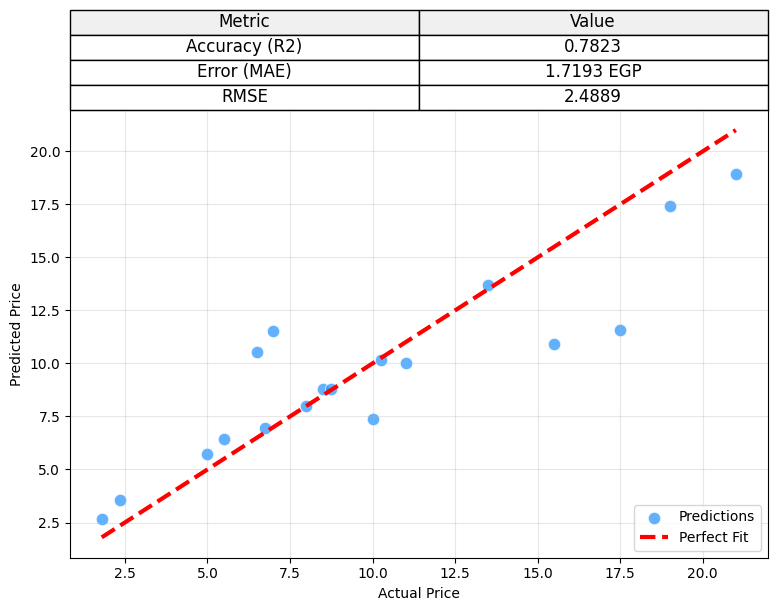


⚙️ Processing Prophet Model...


Importing plotly failed. Interactive plots will not work.
06:54:26 - cmdstanpy - INFO - Chain [1] start processing
06:54:26 - cmdstanpy - INFO - Chain [1] done processing
06:54:26 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
06:54:26 - cmdstanpy - INFO - Chain [1] start processing
06:54:27 - cmdstanpy - INFO - Chain [1] done processing


✅ Showing Plot for Prophet...


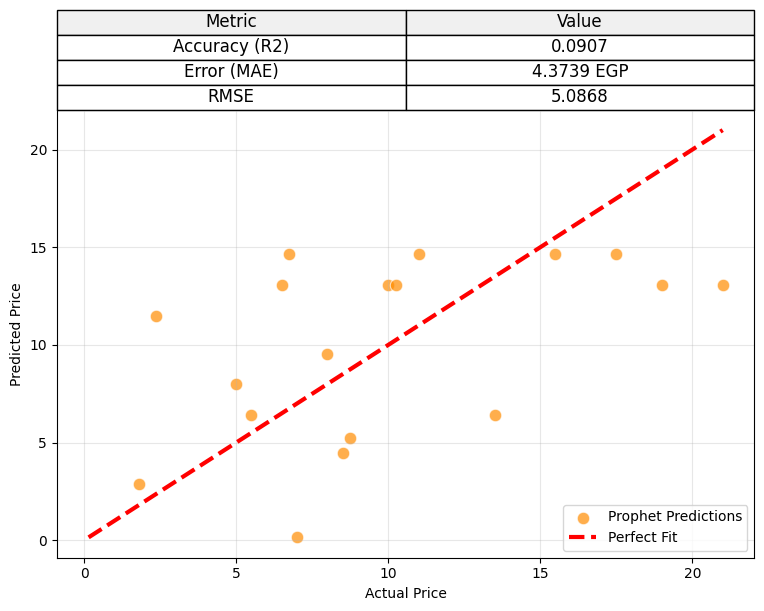

In [7]:
# ==========================================
# 3. الجزء الأول: الرسومات والتقارير للنماذج التقليدية
# ==========================================
print("\n========== PART 1: Model Analysis (Plots & Tables) ==========\n")

for name, model in models.items():
    print(f"⚙️ Processing {name}...")
    
    # النماذج التقليدية (Scikit-Learn)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # الحسابات
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # --- الرسم ---
    fig, ax = plt.subplots(figsize=(9, 7))
    
    # 1. الجدول (فوق)
    table_data = [
        ["Accuracy (R2)", f"{r2:.4f}"],
        ["Error (MAE)", f"{mae:.4f} EGP"],
        ["RMSE", f"{rmse:.4f}"]
    ]
    
    the_table = plt.table(cellText=table_data, colLabels=["Metric", "Value"], 
                          loc='top', cellLoc='center', colColours=['#f0f0f0']*2)
    
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(12)
    the_table.scale(1, 1.8) 
    
    # 2. الجراف (تحت)
    sns.scatterplot(x=y_test, y=y_pred, color='dodgerblue', s=80, alpha=0.7, ax=ax, label='Predictions')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=3, label='Perfect Fit')
    
    # تنسيق
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.subplots_adjust(top=0.75) 
    
    print(f"✅ Showing Plot for {name}...")
    plt.show()


# ==========================================
# 4. تشغيل وتقييم نموذج Prophet 
# ==========================================
print("\n⚙️ Processing Prophet Model...")

from prophet import Prophet

# تجهيز البيانات لـ Prophet (يحتاج عمودين: ds للتاريخ، و y للهدف)
# نفترض هنا أننا سنستخدم عمود 'Year' كممثل للزمن (يمكنك تعديله إذا كان لديك عمود تاريخ أصلي)
prophet_train_df = pd.DataFrame({
    'ds': pd.to_datetime(train_df['Year'].astype(str), format='%Y'),
    'y': train_df['Price']
})

prophet_test_df = pd.DataFrame({
    'ds': pd.to_datetime(test_df['Year'].astype(str), format='%Y'),
    'y': test_df['Price']
})

# بناء التدريب والتنبؤ
prophet_model = Prophet()
prophet_model.fit(prophet_train_df)

# التنبؤ على فترة الاختبار
forecast = prophet_model.predict(prophet_test_df[['ds']])
y_pred_prophet = forecast['yhat'].values
y_test_prophet = prophet_test_df['y'].values

# الحسابات الخاصة بـ Prophet
r2_p = r2_score(y_test_prophet, y_pred_prophet)
mae_p = mean_absolute_error(y_test_prophet, y_pred_prophet)
rmse_p = np.sqrt(mean_squared_error(y_test_prophet, y_pred_prophet))

# --- رسم نموذج Prophet ---
fig, ax = plt.subplots(figsize=(9, 7))

table_data_p = [
    ["Accuracy (R2)", f"{r2_p:.4f}"],
    ["Error (MAE)", f"{mae_p:.4f} EGP"],
    ["RMSE", f"{rmse_p:.4f}"]
]

the_table_p = plt.table(cellText=table_data_p, colLabels=["Metric", "Value"], 
                      loc='top', cellLoc='center', colColours=['#f0f0f0']*2)

the_table_p.auto_set_font_size(False)
the_table_p.set_fontsize(12)
the_table_p.scale(1, 1.8) 

sns.scatterplot(x=y_test_prophet, y=y_pred_prophet, color='darkorange', s=80, alpha=0.7, ax=ax, label='Prophet Predictions')
min_val_p = min(y_test_prophet.min(), y_pred_prophet.min())
max_val_p = max(y_test_prophet.max(), y_pred_prophet.max())
ax.plot([min_val_p, max_val_p], [min_val_p, max_val_p], 'r--', lw=3, label='Perfect Fit')

ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.subplots_adjust(top=0.75) 

print("✅ Showing Plot for Prophet...")
plt.show()

⚙️ Processing Linear Regression...
⚙️ Processing KNN...
⚙️ Processing Random Forest...
⚙️ Processing XGBoost...
⚙️ Processing Ensemble...


06:56:04 - cmdstanpy - INFO - Chain [1] start processing


⚙️ Processing Prophet...


06:56:04 - cmdstanpy - INFO - Chain [1] done processing
06:56:04 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
06:56:04 - cmdstanpy - INFO - Chain [1] start processing
06:56:06 - cmdstanpy - INFO - Chain [1] done processing



========== MODEL PERFORMANCE ==========

            Model  Accuracy (R2)  MAE (Error)     RMSE
          XGBoost       0.908677     1.254032 1.612043
         Ensemble       0.782310     1.719277 2.488886
    Random Forest       0.724874     2.001247 2.798026
Linear Regression       0.670460     2.372242 3.062242
              KNN       0.562145     2.569444 3.529805
          Prophet       0.090676     4.373923 5.086803


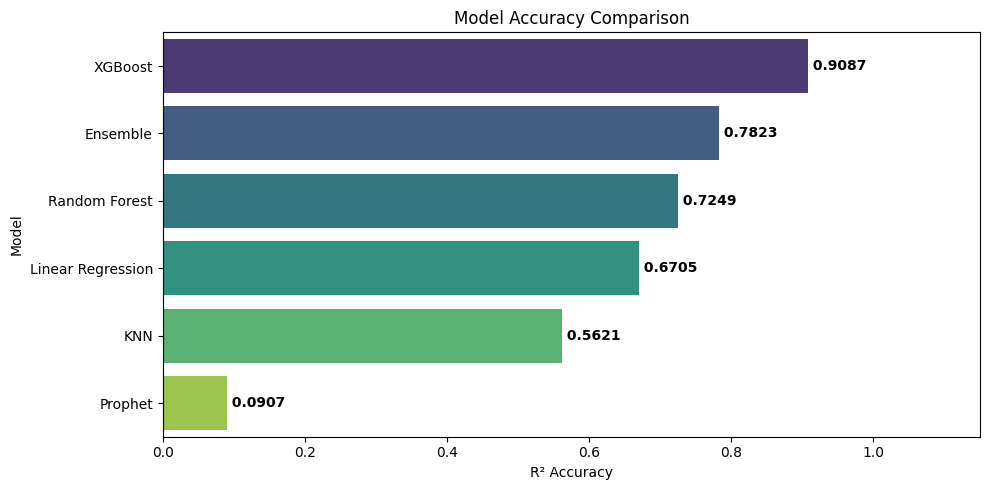

In [10]:
import os
from contextlib import redirect_stderr
from prophet import Prophet

# أضف Prophet إلى القاموس هنا
models['Prophet'] = Prophet()

# --- كود اللوب المعتاد ---
results_list = []

for name, model in models.items():
    print(f"⚙️ Processing {name}...")
    
    if name.lower() == 'prophet':
        
        prophet_train_df = pd.DataFrame({
            'ds': pd.to_datetime(
                train_df['Year'].astype(str),
                format='%Y'
            ),
            'y': train_df['Price']
        })
        
        prophet_test_df = pd.DataFrame({
            'ds': pd.to_datetime(
                test_df['Year'].astype(str),
                format='%Y'
            ),
            'y': test_df['Price']
        })
        
        # إخفاء رسائل Prophet أثناء التدريب
        with open(os.devnull, 'w') as f, redirect_stderr(f):
            model.fit(prophet_train_df)
        
        # التنبؤ
        forecast = model.predict(prophet_test_df[['ds']])
        
        y_pred = forecast['yhat'].values
        y_true = prophet_test_df['y'].values
        
    else:
        # تدريب الموديلات العادية
        model.fit(X_train_scaled, y_train)
        
        # التنبؤ
        y_pred = model.predict(X_test_scaled)
        y_true = y_test
    
    # حساب المقاييس
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # حفظ النتائج
    results_list.append({
        "Model": name,
        "Accuracy (R2)": r2,
        "MAE (Error)": mae,
        "RMSE": rmse
    })

# =========================================================
# ترتيب النتائج حسب R²
# =========================================================

results_df = pd.DataFrame(results_list).sort_values(
    by="Accuracy (R2)",
    ascending=False
)

print("\n========== MODEL PERFORMANCE ==========\n")
print(results_df.to_string(index=False))


# =========================================================
# رسم مقارنة الموديلات
# =========================================================

plt.figure(figsize=(10, 5))

bar_plot = sns.barplot(
    x="Accuracy (R2)",
    y="Model",
    data=results_df,
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("R² Accuracy")
plt.ylabel("Model")

plt.xlim(0, 1.15)

# كتابة قيمة R² على الرسم
for i, v in enumerate(results_df["Accuracy (R2)"]):
    bar_plot.text(
        v,
        i,
        f" {v:.4f}",
        va='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [11]:
import gradio as gr
import pandas as pd
import numpy as np
import html

print("\n========== PART 2: Launching Professional Fuel Price Dashboard ==========\n")


# ============================================================
# 1. PREDICTION FUNCTION
# ============================================================

def predict_fuel(fuel_name, oil, usd, year):

    try:

        # ----------------------------------------------------
        # 1. Processing inputs for Scikit-Learn models
        # ----------------------------------------------------

        fuel_code = FUEL_MAPPING.get(fuel_name, 3)

        inp_data = scaler.transform(
            [[fuel_code, oil, usd, year]]
        )

        # ----------------------------------------------------
        # 2. Model Predictions
        # ----------------------------------------------------

        res_ens = round(
            models["Ensemble"].predict(inp_data)[0],
            2
        )

        res_rf = round(
            models["Random Forest"].predict(inp_data)[0],
            2
        )

        res_xgb = round(
            models["XGBoost"].predict(inp_data)[0],
            2
        )

        res_lr = round(
            models["Linear Regression"].predict(inp_data)[0],
            2
        )

        res_knn = round(
            models["KNN"].predict(inp_data)[0],
            2
        )

        # ----------------------------------------------------
        # 3. Prophet Prediction
        # ----------------------------------------------------

        prophet_input = pd.DataFrame({
            "ds": pd.to_datetime(
                str(int(year)),
                format="%Y"
            )
        }, index=[0])

        forecast = models["Prophet"].predict(
            prophet_input
        )

        res_prophet = round(
            forecast["yhat"].values[0],
            2
        )

        # ----------------------------------------------------
        # 4. Return Dashboard Cards
        #
        # XGBoost = Recommended Final Price
        # ----------------------------------------------------

        return (

            xgboost_feature_card(
                res_xgb,
                year
            ),

            model_card(
                "🤝",
                "Ensemble Model",
                res_ens,
                "Combined Prediction",
                "ensemble"
            ),

            model_card(
                "🌲",
                "Random Forest",
                res_rf,
                "Stable Results",
                "green"
            ),

            model_card(
                "📈",
                "Linear Regression",
                res_lr,
                "Fast & Simple",
                "orange"
            ),

            model_card(
                "📍",
                "KNN",
                res_knn,
                "Good Generalization",
                "purple"
            ),

            prophet_card(
                res_prophet
            )
        )

    except Exception as e:

        err = html.escape(
            str(e)
        )

        error_card = f"""
        <div class="error-card">

            <div class="error-title">
                ⚠ Prediction Error
            </div>

            <div class="error-message">
                {err}
            </div>

        </div>
        """

        return (
            error_card,
            error_card,
            error_card,
            error_card,
            error_card,
            error_card
        )


# ============================================================
# 2. XGBOOST FEATURE CARD
# ============================================================

def xgboost_feature_card(value, year):

    return f"""

    <div class="xgb-feature-card">

        <div class="xgb-feature-left">

            <div class="xgb-icon">
                🚀
            </div>

            <div class="xgb-feature-content">

                <div class="xgb-feature-title">

                    XGBoost

                    <span>
                        (Recommended Final Price)
                    </span>

                </div>

                <div class="xgb-price">

                    {value}

                    <span>
                        EGP / Liter
                    </span>

                </div>

            </div>

        </div>


        <div class="xgb-badge">

            🏆 Best Performing Model

        </div>


        <div class="xgb-glow-line">
            ╱╲╱╲╱╲╱╲╱╲
        </div>

    </div>

    """


# ============================================================
# 3. GENERAL MODEL CARD
# ============================================================

def model_card(
    icon,
    name,
    value,
    badge,
    color
):

    return f"""

    <div class="model-card {color}">

        <div class="model-top">

            <div class="model-icon">

                {icon}

            </div>

            <div class="model-name">

                {name}

            </div>

        </div>


        <div class="model-price">

            {value}

            <span>
                EGP / Liter
            </span>

        </div>


        <div class="model-badge">

            {badge}

        </div>

    </div>

    """


# ============================================================
# 4. PROPHET CARD
# ============================================================

def prophet_card(value):

    return f"""

    <div class="prophet-card">

        <div class="prophet-icon">

            ⏳

        </div>


        <div class="prophet-content">

            <div class="prophet-title">

                Prophet

                <span>
                    (Time-Series Model)
                </span>

            </div>


            <div class="prophet-price">

                {value}

                <span>
                    EGP / Liter
                </span>

            </div>


            <div class="prophet-badge">

                Best for Seasonality

            </div>

        </div>


        <div class="prophet-chart">

            ╱╲__╱╲╱╲__╱╲╱

        </div>

    </div>

    """


# ============================================================
# 5. INITIAL XGBOOST CARD
# ============================================================

initial_xgb = """

<div class="xgb-feature-card">

    <div class="xgb-feature-left">

        <div class="xgb-icon">
            🚀
        </div>

        <div class="xgb-feature-content">

            <div class="xgb-feature-title">

                XGBoost

                <span>
                    (Recommended Final Price)
                </span>

            </div>

            <div class="xgb-price">

                —

                <span>
                    EGP / Liter
                </span>

            </div>

        </div>

    </div>


    <div class="xgb-badge">

        🏆 Best Performing Model

    </div>

</div>

"""


# ============================================================
# 6. INITIAL MODEL CARDS
# ============================================================

initial_ensemble = model_card(
    "🤝",
    "Ensemble Model",
    "—",
    "Combined Prediction",
    "ensemble"
)


initial_rf = model_card(
    "🌲",
    "Random Forest",
    "—",
    "Stable Results",
    "green"
)


initial_lr = model_card(
    "📈",
    "Linear Regression",
    "—",
    "Fast & Simple",
    "orange"
)


initial_knn = model_card(
    "📍",
    "KNN",
    "—",
    "Good Generalization",
    "purple"
)


initial_prophet = prophet_card(
    "—"
)


# ============================================================
# 7. CUSTOM CSS
# ============================================================

custom_css = """

/* =========================================================
   ROOT COLORS
   ========================================================= */

:root {

    /* LIGHT MODE */

    --bg-main: #eef6fc;

    --bg-secondary: #f7fbff;

    --panel-bg: #ffffff;

    --card-bg: #f8fcff;

    --text-main: #10243b;

    --text-secondary: #58718b;

    --text-muted: #71879b;

    --border: #b9d9ee;

    --border-strong: #159fe5;

    --blue: #087fd1;

    --blue-bright: #009cff;

    --cyan: #00aebe;

    --green: #00a879;

    --orange: #ed8b12;

    --purple: #8747df;

}


/* =========================================================
   DARK MODE
   ========================================================= */

.dark {

    --bg-main: #050b14;

    --bg-secondary: #081525;

    --panel-bg: #071827;

    --card-bg: #091c30;

    --text-main: #ffffff;

    --text-secondary: #a9c5dc;

    --text-muted: #7e9ab2;

    --border: rgba(28, 150, 220, 0.48);

    --border-strong: #079fe8;

    --blue: #159eff;

    --blue-bright: #25b5ff;

    --cyan: #00dbe7;

    --green: #00d99b;

    --orange: #ffad28;

    --purple: #a764ff;

}


/* =========================================================
   BODY
   ========================================================= */

body {

    background:

        radial-gradient(
            circle at 10% 10%,
            rgba(0, 156, 255, 0.10),
            transparent 28%
        ),

        radial-gradient(
            circle at 90% 90%,
            rgba(0, 210, 210, 0.08),
            transparent 30%
        ),

        var(--bg-main) !important;

    color:
        var(--text-main) !important;

}


/* =========================================================
   MAIN CONTAINER
   ========================================================= */

.gradio-container {

    max-width:
        1500px !important;

    margin:
        auto !important;

    background:

        linear-gradient(
            135deg,
            var(--bg-main),
            var(--bg-secondary)
        ) !important;

    color:
        var(--text-main) !important;

    font-family:

        "Segoe UI",
        Tahoma,
        Geneva,
        Verdana,
        sans-serif !important;

}


/* =========================================================
   GENERAL TEXT
   ========================================================= */

.gradio-container,
.gradio-container p,
.gradio-container span,
.gradio-container label,
.gradio-container h1,
.gradio-container h2,
.gradio-container h3,
.gradio-container h4 {

    color:
        var(--text-main);

}


/* =========================================================
   HEADER
   ========================================================= */

.dashboard-header {

    padding:
        25px 30px 15px 30px;

}


.logo-title {

    display:
        flex;

    align-items:
        center;

    gap:
        16px;

}


.logo-icon {

    font-size:
        45px;

    filter:

        drop-shadow(
            0 0 12px
            rgba(0, 170, 255, 0.60)
        );

}


.main-title {

    font-size:
        32px !important;

    font-weight:
        800 !important;

    color:
        var(--text-main) !important;

    margin:
        0 !important;

}


.subtitle {

    color:
        var(--blue) !important;

    font-size:
        15px !important;

    margin-top:
        5px;

}


.header-right {

    text-align:
        right;

    color:
        var(--text-secondary) !important;

    font-size:
        14px;

}


.header-right strong {

    color:
        var(--text-main) !important;

}


/* =========================================================
   PANELS
   ========================================================= */

.glass-panel {

    background:
        var(--panel-bg) !important;

    border:
        1px solid var(--border) !important;

    border-radius:
        20px !important;

    padding:
        25px !important;

    box-shadow:

        0 8px 30px
        rgba(22, 90, 130, 0.10) !important;

}


/* =========================================================
   SECTION TITLES
   ========================================================= */

.section-title {

    font-size:
        23px;

    font-weight:
        750;

    color:
        var(--text-main) !important;

    margin-bottom:
        4px;

}


.section-subtitle {

    color:
        var(--text-secondary) !important;

    font-size:
        13px;

    margin-bottom:
        22px;

}


/* =========================================================
   INPUT LABELS
   ========================================================= */

.gradio-container label {

    color:
        var(--text-main) !important;

}


.gradio-container label span {

    color:
        var(--text-main) !important;

    font-weight:
        650 !important;

}


/* =========================================================
   INPUTS
   ========================================================= */

.gradio-container input,
.gradio-container textarea,
.gradio-container select {

    background:
        var(--card-bg) !important;

    color:
        var(--text-main) !important;

    border:
        1px solid var(--border) !important;

    border-radius:
        10px !important;

}


.gradio-container input::placeholder {

    color:
        var(--text-muted) !important;

}


/* =========================================================
   DROPDOWN
   ========================================================= */

.gradio-container .wrap {

    background:
        transparent !important;

    border-radius:
        11px !important;

}


.gradio-container .wrap input {

    color:
        var(--text-main) !important;

}


.gradio-container [role="listbox"] {

    background:
        var(--panel-bg) !important;

    color:
        var(--text-main) !important;

    border:
        1px solid var(--border-strong) !important;

}


.gradio-container [role="option"] {

    color:
        var(--text-main) !important;

}


.gradio-container [role="option"]:hover {

    background:
        rgba(0, 150, 230, 0.12) !important;

}


/* =========================================================
   SLIDERS
   ========================================================= */

.gradio-container input[type="range"] {

    accent-color:
        var(--blue-bright) !important;

}


.gradio-container .range {

    color:
        var(--text-secondary) !important;

}


/* =========================================================
   BUTTON
   ========================================================= */

.predict-btn {

    border:
        none !important;

    border-radius:
        12px !important;

    background:

        linear-gradient(
            90deg,
            #079bea,
            #3657ee
        ) !important;

    color:
        #ffffff !important;

    font-size:
        16px !important;

    font-weight:
        750 !important;

    box-shadow:

        0 8px 22px
        rgba(0, 130, 240, 0.25) !important;

    transition:
        0.25s ease !important;

}


.predict-btn:hover {

    transform:
        translateY(-2px);

    box-shadow:

        0 10px 30px
        rgba(0, 160, 255, 0.40) !important;

}


/* =========================================================
   XGBOOST FEATURE CARD
   ========================================================= */

.xgb-feature-card {

    position:
        relative;

    min-height:
        140px;

    border-radius:
        18px;

    padding:
        23px 26px;

    margin:
        12px 0 20px 0;

    overflow:
        hidden;

    display:
        flex;

    align-items:
        center;

    justify-content:
        space-between;

    background:

        linear-gradient(
            110deg,
            #075e9d,
            #073a66
        ) !important;

    border:
        2px solid #25b5ff !important;

    box-shadow:

        0 0 30px
        rgba(0, 150, 255, 0.22) !important;

}


.xgb-feature-left {

    display:
        flex;

    align-items:
        center;

    gap:
        20px;

}


.xgb-icon {

    width:
        62px;

    height:
        62px;

    border-radius:
        16px;

    display:
        flex;

    align-items:
        center;

    justify-content:
        center;

    font-size:
        32px;

    background:
        rgba(0, 190, 255, 0.16);

    border:
        1px solid
        rgba(100, 220, 255, 0.55);

}


.xgb-feature-title {

    font-size:
        22px;

    font-weight:
        850;

    color:
        #ffffff !important;

}


.xgb-feature-title span {

    font-size:
        14px;

    font-weight:
        400;

    color:
        #c8eaff !important;

}


.xgb-price {

    font-size:
        44px !important;

    font-weight:
        900 !important;

    margin-top:
        5px;

    color:
        #ffffff !important;

    text-shadow:

        0 2px 12px
        rgba(0, 0, 0, 0.25);

}


.xgb-price span {

    font-size:
        14px !important;

    color:
        #b8def3 !important;

    font-weight:
        500 !important;

}


.xgb-badge {

    position:
        absolute;

    top:
        18px;

    right:
        20px;

    padding:
        8px 14px;

    border-radius:
        20px;

    background:
        rgba(0, 185, 255, 0.18);

    border:
        1px solid
        rgba(110, 220, 255, 0.70);

    color:
        #d8f5ff !important;

    font-size:
        12px;

    font-weight:
        750;

}


.xgb-glow-line {

    position:
        absolute;

    right:
        20px;

    bottom:
        15px;

    font-size:
        34px;

    letter-spacing:
        4px;

    color:
        #35c2ff !important;

    opacity:
        0.65;

}


/* =========================================================
   MODEL CARDS
   ========================================================= */

.model-card {

    min-height:
        155px;

    border-radius:
        16px;

    padding:
        18px 20px;

    margin:
        5px;

    background:
        var(--card-bg) !important;

    position:
        relative;

    overflow:
        hidden;

    transition:
        0.25s ease;

    box-shadow:

        0 5px 18px
        rgba(0, 70, 110, 0.06);

}


.model-card:hover {

    transform:
        translateY(-3px);

}


/* Ensemble */

.model-card.ensemble {

    border:
        1px solid #00aebe !important;

}


/* Random Forest */

.model-card.green {

    border:
        1px solid #00c991 !important;

}


/* Linear Regression */

.model-card.orange {

    border:
        1px solid #f59d21 !important;

}


/* KNN */

.model-card.purple {

    border:
        1px solid #9250ed !important;

}


/* =========================================================
   MODEL TOP
   ========================================================= */

.model-top {

    display:
        flex;

    align-items:
        center;

    gap:
        12px;

}


.model-icon {

    width:
        45px;

    height:
        45px;

    border-radius:
        50%;

    display:
        flex;

    align-items:
        center;

    justify-content:
        center;

    font-size:
        23px;

    background:
        rgba(30, 130, 210, 0.13);

}


.model-name {

    font-size:
        17px;

    font-weight:
        750;

    color:
        var(--text-main) !important;

}


/* =========================================================
   MODEL PRICE
   ========================================================= */

.model-price {

    font-size:
        29px !important;

    font-weight:
        850 !important;

    margin-top:
        15px;

    color:
        var(--text-main) !important;

}


.dark .model-price {

    color:
        #ffffff !important;

    text-shadow:

        0 0 8px
        rgba(100, 210, 255, 0.15) !important;

}


.model-price span {

    font-size:
        12px !important;

    color:
        var(--text-secondary) !important;

    font-weight:
        500 !important;

}


.dark .model-price span {

    color:
        #a8c6dc !important;

}


/* =========================================================
   MODEL BADGE
   ========================================================= */

.model-badge {

    display:
        inline-block;

    margin-top:
        10px;

    padding:
        5px 10px;

    border-radius:
        15px;

    background:
        rgba(20, 140, 220, 0.13);

    color:
        var(--blue) !important;

    font-size:
        11px;

    font-weight:
        650;

}


.dark .model-badge {

    color:
        #91dcff !important;

    background:
        rgba(20, 140, 220, 0.20);

}


/* =========================================================
   PROPHET
   ========================================================= */

.prophet-card {

    min-height:
        125px;

    border-radius:
        16px;

    padding:
        20px;

    margin-top:
        10px;

    display:
        flex;

    align-items:
        center;

    gap:
        16px;

    background:
        var(--card-bg) !important;

    border:
        1px solid #00bfcf !important;

    box-shadow:

        0 5px 18px
        rgba(0, 130, 160, 0.07);

}


.prophet-icon {

    width:
        55px;

    height:
        55px;

    border-radius:
        50%;

    display:
        flex;

    align-items:
        center;

    justify-content:
        center;

    background:
        rgba(0, 185, 220, 0.14);

    border:
        1px solid #00cfe2;

    font-size:
        27px;

}


.prophet-content {

    flex:
        1;

}


.prophet-title {

    font-size:
        18px;

    font-weight:
        800;

    color:
        var(--text-main) !important;

}


.prophet-title span {

    font-size:
        13px;

    color:
        var(--text-secondary) !important;

    font-weight:
        400;

}


.prophet-price {

    font-size:
        29px !important;

    font-weight:
        850 !important;

    margin-top:
        6px;

    color:
        var(--text-main) !important;

}


.dark .prophet-price {

    color:
        #ffffff !important;

    text-shadow:

        0 0 8px
        rgba(0, 220, 240, 0.12);

}


.prophet-price span {

    font-size:
        12px !important;

    color:
        var(--text-secondary) !important;

}


.prophet-badge {

    display:
        inline-block;

    margin-top:
        7px;

    padding:
        5px 11px;

    border-radius:
        15px;

    background:
        rgba(0, 190, 220, 0.13);

    color:
        var(--cyan) !important;

    font-size:
        11px;

}


.dark .prophet-badge {

    color:
        #7ceaff !important;

    background:
        rgba(0, 190, 220, 0.20);

}


.prophet-chart {

    color:
        var(--cyan) !important;

    font-size:
        25px;

    letter-spacing:
        2px;

}


/* =========================================================
   KEY INSIGHT
   ========================================================= */

.insight-card {

    margin-top:
        18px;

    padding:
        17px 20px;

    border-radius:
        14px;

    background:
        rgba(0, 150, 220, 0.055);

    border:
        1px solid var(--border);

    color:
        var(--text-secondary) !important;

}


.insight-title {

    color:
        var(--blue) !important;

    font-weight:
        800;

    font-size:
        14px;

    margin-bottom:
        5px;

}


/* =========================================================
   ERROR
   ========================================================= */

.error-card {

    padding:
        20px;

    border-radius:
        12px;

    background:
        rgba(220, 40, 55, 0.08);

    border:
        1px solid #e44b5b;

    color:
        #c9283c !important;

}


.error-title {

    font-weight:
        800;

    margin-bottom:
        6px;

}


.error-message {

    font-size:
        13px;

}


.dark .error-card {

    color:
        #ff9ca7 !important;

    background:
        rgba(150, 20, 30, 0.25);

}


/* =========================================================
   FOOTER
   ========================================================= */

footer {

    display:
        none !important;

}


/* =========================================================
   MOBILE
   ========================================================= */

@media (max-width: 900px) {

    .header-right {

        display:
            none;

    }


    .main-title {

        font-size:
            25px !important;

    }


    .xgb-price {

        font-size:
            34px !important;

    }


    .model-price,
    .prophet-price {

        font-size:
            25px !important;

    }

}

"""


# ============================================================
# 8. BUILD DASHBOARD
# ============================================================

with gr.Blocks(

    theme=gr.themes.Default(
        primary_hue="blue",
        secondary_hue="cyan"
    ),

    css=custom_css

) as demo:


    # ========================================================
    # HEADER
    # ========================================================

    gr.HTML("""

    <div class="dashboard-header">

        <div style="
            display:flex;
            justify-content:space-between;
            align-items:center;
        ">


            <div class="logo-title">

                <div class="logo-icon">
                    ⛽
                </div>


                <div>

                    <div class="main-title">

                        Fuel Price Prediction

                    </div>


                    <div class="subtitle">

                        Smarter Forecasts
                        &nbsp; • &nbsp;
                        Better Decisions

                    </div>

                </div>

            </div>


            <div class="header-right">

                <strong>
                    Data
                </strong>

                &nbsp; + &nbsp;

                <strong>
                    Machine Learning
                </strong>

                &nbsp; = &nbsp;

                <span style="
                    color:#159eff;
                ">

                    Accurate Fuel Price Forecasts

                </span>

            </div>

        </div>

    </div>

    """)


    # ========================================================
    # MAIN LAYOUT
    # ========================================================

    with gr.Row(
        equal_height=False
    ):


        # ====================================================
        # INPUT PANEL
        # ====================================================

        with gr.Column(

            scale=4,

            elem_classes=[
                "glass-panel"
            ]

        ):


            gr.HTML("""

            <div class="section-title">

                ⚙️ Input Parameters

            </div>


            <div class="section-subtitle">

                Enter the following details
                to predict the fuel price.

            </div>

            """)


            # ------------------------------------------------
            # Fuel Type
            # ------------------------------------------------

            fuel_input = gr.Dropdown(

                choices=list(
                    FUEL_MAPPING.keys()
                ),

                label="Fuel Type",

                value="Octane 92",

                interactive=True

            )


            # ------------------------------------------------
            # Global Oil Price
            # ------------------------------------------------

            oil_input = gr.Slider(

                minimum=50,

                maximum=150,

                value=73.7,

                step=0.1,

                label="Global Oil Price ($)",

                interactive=True

            )


            # ------------------------------------------------
            # USD Exchange Rate
            # ------------------------------------------------

            usd_input = gr.Slider(

                minimum=30,

                maximum=60,

                value=50.0,

                step=0.1,

                label="USD Exchange Rate (EGP)",

                interactive=True

            )


            # ------------------------------------------------
            # Target Year
            # ------------------------------------------------

            year_input = gr.Slider(

                minimum=2020,

                maximum=2030,

                value=2026,

                step=1,

                label="Target Year",

                interactive=True

            )


            gr.HTML("""

            <div style="
                margin-top:5px;
                padding:10px 0;
                color:var(--text-secondary);
                font-size:12px;
            ">

                💡 Adjust the parameters
                using the sliders or enter
                the value manually.

            </div>

            """)


            # ------------------------------------------------
            # Prediction Button
            # ------------------------------------------------

            predict_btn = gr.Button(

                "✨  Predict Fuel Price",

                variant="primary",

                size="lg",

                elem_classes=[
                    "predict-btn"
                ]

            )


        # ====================================================
        # PREDICTIONS PANEL
        # ====================================================

        with gr.Column(

            scale=6,

            elem_classes=[
                "glass-panel"
            ]

        ):


            # ------------------------------------------------
            # Dashboard Header
            # ------------------------------------------------

            with gr.Row():


                with gr.Column(
                    scale=7
                ):

                    gr.HTML("""

                    <div class="section-title">

                        📊 Model Predictions Dashboard

                    </div>


                    <div class="section-subtitle">

                        Predicted Fuel Price
                        (EGP per Liter)

                    </div>

                    """)


                with gr.Column(
                    scale=2
                ):

                    gr.HTML("""

                    <div class="year-badge">

                        🎯 Target Year:
                        <strong>2026</strong>

                    </div>

                    """)


            # ------------------------------------------------
            # XGBoost - TOP MODEL
            # ------------------------------------------------

            out_xgb = gr.HTML(

                value=initial_xgb

            )


            # ------------------------------------------------
            # Ensemble + Random Forest
            # ------------------------------------------------

            with gr.Row():


                with gr.Column():

                    out_ens = gr.HTML(

                        value=initial_ensemble

                    )


                with gr.Column():

                    out_rf = gr.HTML(

                        value=initial_rf

                    )


            # ------------------------------------------------
            # Linear Regression + KNN
            # ------------------------------------------------

            with gr.Row():


                with gr.Column():

                    out_lr = gr.HTML(

                        value=initial_lr

                    )


                with gr.Column():

                    out_knn = gr.HTML(

                        value=initial_knn

                    )


            # ------------------------------------------------
            # Prophet
            # ------------------------------------------------

            out_prophet = gr.HTML(

                value=initial_prophet

            )


            # ------------------------------------------------
            # Key Insight
            # ------------------------------------------------

            gr.HTML("""

            <div class="insight-card">

                <div class="insight-title">

                    💡 Key Insight

                </div>


                XGBoost is the best-performing
                model in this project and is used
                as the recommended final prediction.

            </div>

            """)


    # ========================================================
    # EVENT BINDING
    # ========================================================

    predict_btn.click(

        fn=predict_fuel,

        inputs=[

            fuel_input,
            oil_input,
            usd_input,
            year_input

        ],

        outputs=[

            out_xgb,
            out_ens,
            out_rf,
            out_lr,
            out_knn,
            out_prophet

        ]

    )


# ============================================================
# 9. LAUNCH
# ============================================================

demo.launch()


========== PART 2: Launching Professional Fuel Price Dashboard ==========

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
